**Phase 2: Unsupervised Learning**


**Unsupervised Algorithm 1: K-Means Clustering**

K-Means clustering was selected due to its efficiency and suitability for numerical medical datasets such as the Indian Liver Patient Records dataset. Since the dataset consists primarily of continuous clinical variables (e.g., bilirubin levels, liver enzymes, and protein measurements), K-Means is well-suited for identifying groups of patients with similar physiological characteristics.

K-Means assumes that clusters are spherical and separable in feature space, which is reasonable after feature scaling using StandardScaler. Additionally, the algorithm is computationally efficient and interpretable, making it appropriate for datasets of this size (~580 samples).

In the context of this project, K-Means is used to uncover hidden patient subgroups that are not explicitly defined by the disease label. These clusters can later be used to enhance the advice system by providing group-based explanations and personalized recommendations.

**Preprossessing:**
Before applying clustering, the dataset must be prepared appropriately:

- The target label is removed, since clustering is unsupervised
- The features are scaled to ensure fair distance calculations

In [44]:
# preprocessing the dataset: load dataset without lables

import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy import stats

# Load dataset (no lables)
X_train = pd.read_csv("Preprocessed_Data/X_train.csv")
X_test = pd.read_csv("Preprocessed_Data/X_test.csv")

# Combine dataset for clustering 
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)

print("Shape of clustering dataset:", X.shape)

#feature scaling for  distance based algorithms

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data successfully scaled for K-Means clustering.")

Shape of clustering dataset: (764, 11)
Data successfully scaled for K-Means clustering.


Cluster Determination:
The Elbow Method is used to determine the optimal number of clusters by analyzing WCSS.

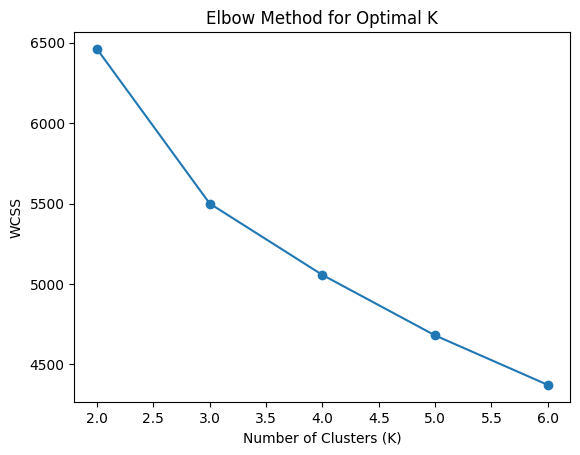

Removed features: [3]


In [45]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# Compute WCSS for different values of K

wcss = []

#for k in range(1, 11):
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.plot(range(2, 7), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

##
# Remove highly correlated features
corr_matrix = pd.DataFrame(X_scaled).corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

X_reduced = pd.DataFrame(X_scaled).drop(columns=to_drop)

print("Removed features:", to_drop)

**Implementation:**

The optimal number of clusters was selected using the Elbow Method by analyzing the Within-Cluster Sum of Squares (WCSS). K=3 was chosen as it provides a balance between model simplicity and cluster compactness.

In [46]:
##
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)
##


# Train K-Means with optimal K
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Assign cluster labels
#clusters = kmeans.fit_predict(X_scaled)
clusters = kmeans.fit_predict(X_pca)

# Add cluster labels to dataset
X['Cluster'] = clusters

# WCSS (Final model)
print("WCSS:", kmeans.inertia_)



WCSS: 5272.9574965812


**Evaluation:**
Cluster quality is evaluated using:
- Silhouette Score 
- Davies-Bouldin Index 
- WCSS 
- BCubed Precision/Recall

External evaluation was performed using a label-mapping approximation, where each cluster was assigned the majority class label. BCubed metrics are approximated due to lack of true clustering ground truth.

In [47]:
from sklearn.metrics import silhouette_score
# silhouette score
sil_score = silhouette_score(X_pca, clusters)

# silhouette_score(X_scaled, clusters)n
print("Silhouette Score:", sil_score)

from sklearn.metrics import davies_bouldin_score
# Davies-Bouldin Index
#db_index = davies_bouldin_score(X_scaled, clusters)
db_index = davies_bouldin_score(X_pca, clusters)
print("Davies-Bouldin Index:", db_index)

#Bcubed: External Evaluation
from sklearn.metrics import precision_score, recall_score
import numpy as np

# Load true labels ONLY for evaluation
y_true = pd.read_csv("Preprocessed_Data/y_train.csv")
y_true = pd.concat([y_true, pd.read_csv("Preprocessed_Data/y_test.csv")], axis=0).squeeze()

# Map clusters to majority class
def cluster_to_class_map(clusters, y_true):
    mapping = {}
    for c in np.unique(clusters):
        mask = clusters == c
        mapping[c] = y_true[mask].mode()[0]
    return mapping

mapping = cluster_to_class_map(clusters, y_true)

# Convert clusters to predicted labels
y_pred_mapped = np.array([mapping[c] for c in clusters])

# Approximate BCubed using majority mapping
print("BCubed Precision:", precision_score(y_true, y_pred_mapped))
print("BCubed Recall:", recall_score(y_true, y_pred_mapped))

# Save evaluation metrics to file
with open('Unsupervised_Learning/cluster_profiles.txt', 'w') as f:
    f.write("K-Means Clustering Results\n")
    f.write("-" * 40 + "\n")
    f.write(f"WCSS: {kmeans.inertia_}\n")
    f.write(f"Silhouette Score: {sil_score:.4f}\n")
    f.write(f"Davies-Bouldin Index: {db_index:.4f}\n")
    f.write(f"BCubed Precision: {precision_score(y_true, y_pred_mapped):.4f}\n")
    f.write(f"BCubed Recall: {recall_score(y_true, y_pred_mapped):.4f}\n")

print("Final K used:", kmeans.n_clusters)
# Save cCluster feature averages
cluster_profiles = X.groupby('Cluster').mean()
cluster_profiles.to_csv('Unsupervised_Learning/clustering_results/cluster_feature_averages.csv')

Silhouette Score: 0.1881856884765011
Davies-Bouldin Index: 1.6506732292734079
BCubed Precision: 0.9612403100775194
BCubed Recall: 0.3054187192118227
Final K used: 3


**Visualization:**
PCA was used to project high-dimensional data into 2D space for visualization of cluster separation.

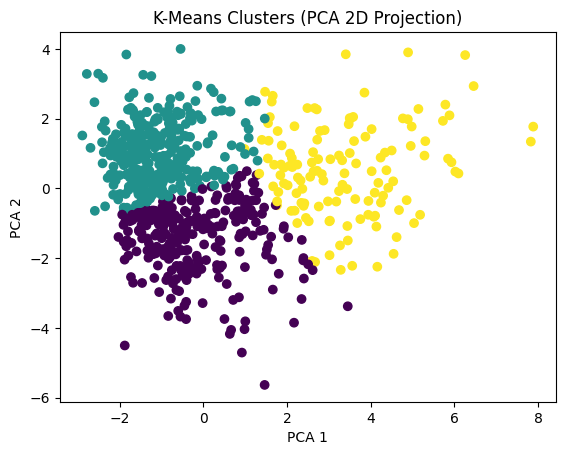

In [48]:
from sklearn.decomposition import PCA

# Reduce dimensions to 2D
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_scaled)

# Scatter plot of clusters
plt.scatter(X_pca[:, 0], X_vis[:, 1], c=clusters, cmap='viridis')
plt.title("K-Means Clusters (PCA 2D Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.savefig('Unsupervised_Learning/clustering_results/pca_clusters.png')
plt.show()





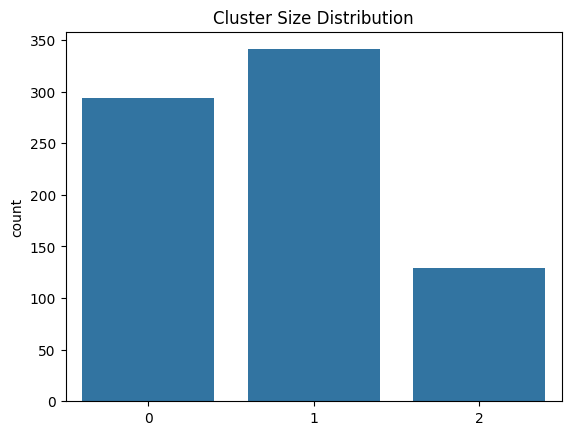

In [49]:
import seaborn as sns
# Plot cluster sizes
sns.countplot(x=clusters)
plt.title("Cluster Size Distribution")
plt.savefig('Unsupervised_Learning/clustering_results/cluster_sizes.png')
plt.show()

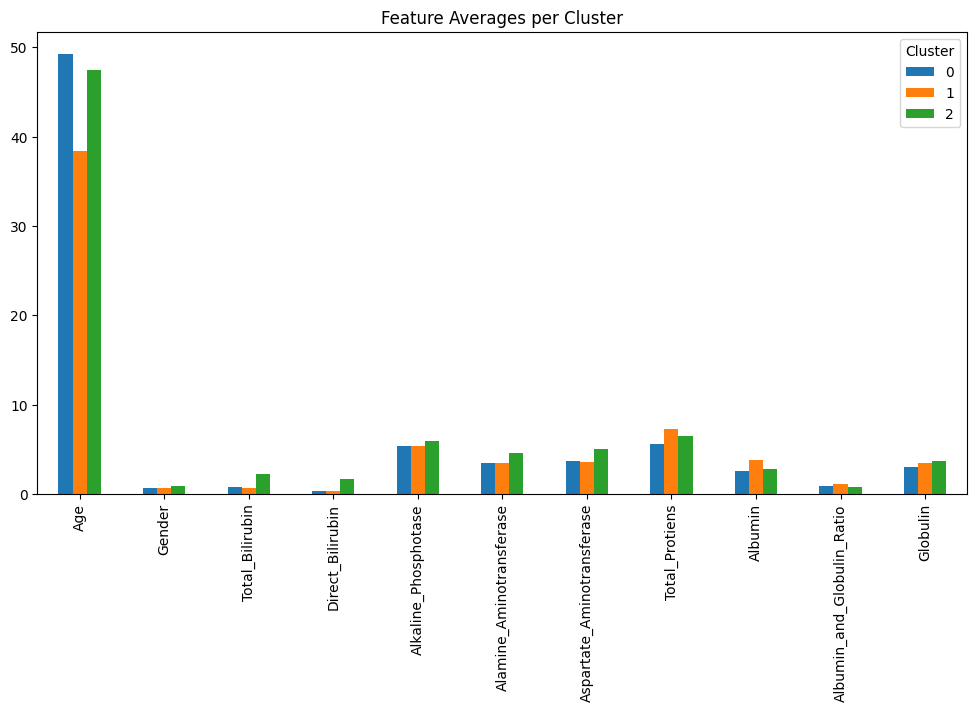

In [50]:
# Analyze average feature values per cluster
X['Cluster'] = clusters

X.groupby('Cluster').mean().T.plot(kind='bar', figsize=(12,6))
plt.title("Feature Averages per Cluster")
plt.savefig('Unsupervised_Learning/clustering_results/feature_averages.png')
plt.show()

**Cluster Profiles**:

Cluster 0: Patients with relatively normal liver enzyme levels and low bilirubin.

Cluster 1: Patients with elevated bilirubin and abnormal liver enzyme levels, indicating possible liver dysfunction.

Cluster 2: Patients with moderate or borderline biomarker levels, potentially representing an early-risk group.

**Integration Strategy:**

K-Means clustering enhances the existing supervised learning system by grouping patients into clinically similar profiles. Instead of providing only individual predictions, the system can now also generate cluster-based explanations, like which patient group the user belongs to.

For example, when a patient belongs to a high-risk cluster, the Generative AI component can provide tailored advice such as:
“Patients in this group typically show elevated liver enzymes and are often advised to undergo further diagnostic testing.”

This improves interpretability and enables more personalized, context-aware recommendations in the advice system.

**Interpretation:**

The clustering results indicate that the Indian Liver Patient dataset does not exhibit strong natural cluster separability. The Silhouette Score (0.188) and Davies-Bouldin Index (1.65) suggest overlapping cluster boundaries and weak structural separation.

However, the high BCubed Precision (0.96) indicates that when the model assigns patients to the same cluster, those patients tend to share similar characteristics. In contrast, the low BCubed Recall (0.30) shows that clusters do not fully capture the underlying disease distribution.

This suggests that liver disease progression is continuous rather than discrete, making it inherently difficult for K-Means to identify well-separated groups. Despite this limitation, the clusters still provide useful patient groupings for explanation and recommendation purposes within the advice system.

**Challenges & Limitations:**

One key limitation of K-Means is its assumption of spherical clusters, which may not fully represent the complex structure of medical data. This is supported by the low Silhouette Score, which indicates weak separation and overlapping patient profiles.

Additionally, the dataset exhibits continuous variation in medical features, meaning there are no clear boundaries between patient groups. This naturally reduces the effectiveness of distance-based clustering methods like K-Means.

Finally, the use of BCubed metrics is only an approximation in this context, since true clustering ground truth does not exist and disease labels are only used as a proxy for evaluation.